In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q albumentations opencv-python segmentation-models-pytorch scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.2 MB/s eta 0:00:00


In [3]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split

# Set random seeds so results are same every run
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
DATA_PATH = "/content/drive/MyDrive/satellite-project/Data/DubaiDataset"

In [5]:
# Change these values to experiment easily
CFG = {
    "patch_size"  : 256,
    "stride"      : 128,   # overlap between patches → more data
    "num_classes" : 6,
    "batch_size"  : 16,
    "epochs"      : 30,
    "lr"          : 1e-4,
    "val_size"    : 0.2,
    "ignore_index": 5,     # class 5 = Unlabeled, skip it in loss
}

CLASS_NAMES = ["Building", "Land", "Road", "Vegetation", "Water", "Unlabeled"]

In [6]:
import os

print(os.listdir(DATA_PATH))

['classes.json', 'Tile 7', 'Tile 6', 'Tile 5', 'Tile 1', 'Tile 2', 'Tile 8', 'Tile 3', 'Tile 4']


In [7]:
tile_path = os.path.join(DATA_PATH, "Tile 1")
print(os.listdir(tile_path))

['images', 'masks']


In [8]:
# Load Images & Masks

image_paths = []
mask_paths  = []

for tile in sorted(os.listdir(DATA_PATH)):
    tile_path = os.path.join(DATA_PATH, tile)

    if not os.path.isdir(tile_path):
        continue

    img_dir  = os.path.join(tile_path, "images")
    mask_dir = os.path.join(tile_path, "masks")

    if not os.path.exists(img_dir) or not os.path.exists(mask_dir):
        continue

    for img_name in sorted(os.listdir(img_dir)):
        img_path  = os.path.join(img_dir, img_name)
        # handle both .jpg → .png and .png → .png
        mask_name = os.path.splitext(img_name)[0] + ".png"
        mask_path = os.path.join(mask_dir, mask_name)

        if os.path.exists(mask_path):
            image_paths.append(img_path)
            mask_paths.append(mask_path)

print(f"Found {len(image_paths)} image-mask pairs")

Found 72 image-mask pairs


| Change            | Why                   |
| ----------------- | --------------------- |
| BGR → RGB         | correct label mapping |
| sorted()          | prevent mismatch      |
| mask exists check | avoid crash           |
| keep list         | variable image size   |


In [9]:
#  Create Patches

patch_size = CFG["patch_size"]
stride     = CFG["stride"]

image_patches = []
mask_patches  = []

for img_path, mask_path in tqdm(zip(image_paths, mask_paths), total=len(image_paths)):

    image = cv2.cvtColor(cv2.imread(img_path),  cv2.COLOR_BGR2RGB)
    mask  = cv2.cvtColor(cv2.imread(mask_path), cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):
            image_patches.append(image[i:i+patch_size, j:j+patch_size])
            mask_patches.append(mask [i:i+patch_size, j:j+patch_size])

print(f"Total patches: {len(image_patches)}")
print(f"Patch shape  : {image_patches[0].shape}")

100%|██████████| 72/72 [01:57<00:00,  1.63s/it]

Total patches: 4464
Patch shape  : (256, 256, 3)


 1. Why patching is needed?
 Original dataset has only 72 large images (~644x797),
 which is too small for deep learning.
 So we divide each image into smaller patches (256x256)
 to increase number of training samples.

 2. Dataset size improvement:
 Before patching → 72 samples
 After patching → 1305 samples
 This helps the model learn better.

 3. Why patch_size = 256?
 - Standard size for U-Net
 - Fits into GPU memory
 - Works well with downsampling layers (divisible by 32)

 4. Why we used this loop?
 range(0, h - patch_size + 1, patch_size)
 ensures:
 - only full patches are taken
 - avoids incomplete edge patches

 5. Why no overlap?
 We use stride = patch_size → non-overlapping patches
 This keeps implementation simple.
 (Later improvement: use overlap for better accuracy)

 6. Data format after patching:
 image_patches → list of (256,256,3)
 mask_patches  → list of (256,256,3)


In [10]:
# RGB Mask → Label Numbers

# Map each colour to a class number
def hex_to_rgb(h):
    h = h.lstrip("#")
    return (int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16))

COLOR_TO_CLASS = {
    hex_to_rgb("#3C1098"): 0,  # Building
    hex_to_rgb("#8429F6"): 1,  # Land
    hex_to_rgb("#6EC1E4"): 2,  # Road
    hex_to_rgb("#FEDD3A"): 3,  # Vegetation
    hex_to_rgb("#E2A929"): 4,  # Water
    hex_to_rgb("#9B9B9B"): 5,  # Unlabeled
}

def rgb_to_label(mask):
    # Pack R,G,B into one integer per pixel for fast comparison
    packed = (mask[:,:,0].astype(np.int32) * 65536 +
              mask[:,:,1].astype(np.int32) * 256   +
              mask[:,:,2].astype(np.int32))

    label = np.full(packed.shape, fill_value=5, dtype=np.uint8)  # default = Unlabeled

    for (r, g, b), cls_id in COLOR_TO_CLASS.items():
        key = r * 65536 + g * 256 + b
        label[packed == key] = cls_id

    return label

# Convert all mask patches
label_patches = [rgb_to_label(m) for m in tqdm(mask_patches, desc="Converting masks")]

# Check all classes are present
all_classes = sorted(set(np.concatenate([np.unique(l) for l in label_patches])))
print("Classes found:", [CLASS_NAMES[c] for c in all_classes])

Converting masks: 100%|██████████| 4464/4464 [00:03<00:00, 1373.58it/s]


Classes found: ['Building', 'Land', 'Road', 'Vegetation', 'Water', 'Unlabeled']


In [11]:
all_unique = set()

for label in label_patches:
    all_unique.update(np.unique(label))

print("All classes in dataset:", sorted(all_unique))

All classes in dataset: [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5)]


In [12]:
# Check Class Imbalance

# ── Count pixels per class ────────────────────────────────────────
pixel_counts = np.zeros(CFG["num_classes"], dtype=np.int64)

for label in label_patches:
    for cls in range(CFG["num_classes"]):
        pixel_counts[cls] += (label == cls).sum()

total_pixels = pixel_counts.sum()

print(f"\n{'Class':<14} {'Pixels':>12} {'%':>8}  Imbalance")
print("-" * 50)
for i, (name, count) in enumerate(zip(CLASS_NAMES, pixel_counts)):
    pct = 100 * count / total_pixels
    bar = "█" * int(pct / 2)
    print(f"{name:<14} {count:>12,} {pct:>7.1f}%  {bar}")

# ── Compute class weights (inverse frequency) ─────────────────────
# Rare class → high weight  |  Common class → low weight
# Skip Unlabeled (index 5)
valid_counts = pixel_counts[:5].astype(np.float32)
class_weights = valid_counts.sum() / (5 * valid_counts)
class_weights = np.append(class_weights, 0.0)  # weight=0 for Unlabeled

print("\nComputed class weights (use these in loss):")
for name, w in zip(CLASS_NAMES, class_weights):
    print(f"  {name:<14}: {w:.3f}")

CLASS_WEIGHTS_TENSOR = torch.tensor(class_weights, dtype=torch.float32).to(device)


Class                Pixels        %  Imbalance
--------------------------------------------------
Building         39,017,947    13.3%  ██████
Land            157,102,274    53.7%  ██████████████████████████
Road             28,023,212     9.6%  ████
Vegetation       30,363,081    10.4%  █████
Water            35,182,267    12.0%  ██████
Unlabeled         2,863,923     1.0%  

Computed class weights (use these in loss):
  Building      : 1.485
  Land          : 0.369
  Road          : 2.067
  Vegetation    : 1.908
  Water         : 1.647
  Unlabeled     : 0.000


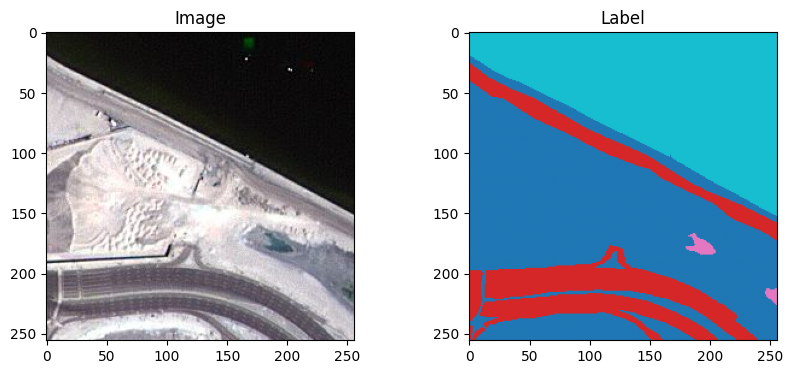

In [13]:
import random

idx = random.randint(0, len(image_patches)-1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(image_patches[idx])

plt.subplot(1,2,2)
plt.title("Label")
plt.imshow(label_patches[idx], cmap='tab10')

plt.show()


# NOTES: RGB → LABEL CONVERSION


 1. Why convert RGB masks?
 Original masks are color images (RGB),
 but deep learning models require class indices (0–5).

 2. What this step does:
 Converts each pixel color → corresponding class ID.

 Example:
 water (RGB) → 0
 land  (RGB) → 1


 3. Output format:
 Before → (256,256,3)
 After  → (256,256)






In [14]:
# Train / Val Split

X_train, X_val, y_train, y_val = train_test_split(
    image_patches, label_patches,
    test_size    = CFG["val_size"],
    random_state = 42
)

print(f"Train patches : {len(X_train)}")
print(f"Val patches   : {len(X_val)}")

Train patches : 3571
Val patches   : 893


In [15]:
# Albumentations Transform
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussianBlur(blur_limit=3, p=0.2),          # fixed: GaussNoise → GaussianBlur
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),  # correct API for new albumentations
    A.RandomGamma(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

/tmp/ipykernel_2698/3332587199.py:8: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),  # correct API for new albumentations


In [16]:
#  Dataset Class
class SatelliteDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images    = images
        self.masks     = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx].copy()   # .copy() prevents albumentations bug
        mask  = self.masks[idx].copy()

        if self.transform:
            result = self.transform(image=image, mask=mask)
            image  = result["image"]
            mask   = result["mask"]

        return image, mask.long()

In [17]:
# DataLoaders

train_dataset = SatelliteDataset(X_train, y_train, train_transform)
val_dataset   = SatelliteDataset(X_val,   y_val,   val_transform)

train_loader = DataLoader(train_dataset, batch_size=CFG["batch_size"],
                          shuffle=True,  num_workers=2, pin_memory=True)

val_loader   = DataLoader(val_dataset,   batch_size=CFG["batch_size"],
                          shuffle=False, num_workers=2, pin_memory=True)


imgs, msks = next(iter(train_loader))
print("Images shape:", imgs.shape)   # [8, 3, 256, 256]
print("Masks  shape:", msks.shape)   # [8, 256, 256]
print("Image range :", imgs.min().item(), "→", imgs.max().item())
print("Mask classes:", torch.unique(msks).tolist())

Images shape: torch.Size([16, 3, 256, 256])
Masks  shape: torch.Size([16, 256, 256])
Image range : -2.1179039478302 → 2.6399998664855957
Mask classes: [0, 1, 2, 3, 4, 5]


[Batch, Channels, Height, Width]

[8, 3, 256, 256]

Masks
[Batch, Height, Width]
[8, 256, 256]


In [18]:
# Check mask values
print(torch.unique(msks))

tensor([0, 1, 2, 3, 4, 5])


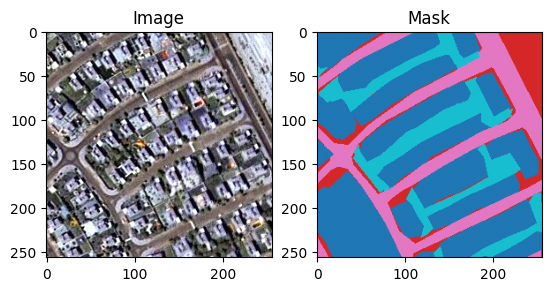

In [19]:
img = imgs[0].permute(1,2,0).cpu().numpy()

# undo normalization
mean = np.array([0.485,0.456,0.406])
std = np.array([0.229,0.224,0.225])

img = (img * std) + mean
img = np.clip(img, 0, 1)

msks = msks[0].cpu().numpy()

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(msks, cmap='tab10')
plt.title("Mask")

plt.show()

# RAW DATA → PATCHES → LABELS → TENSORS → BATCHES

# MODEL + TRAINING

In [20]:
# Model

model = smp.Unet(
    encoder_name    = "efficientnet-b3",
    encoder_weights = "imagenet",
    in_channels     = 3,
    classes         = CFG["num_classes"],
    activation      = None,   # IMPORTANT: raw logits, not softmax
)

model = model.to(device)
print("Model ready. Parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad) // 1_000_000, "M")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Model ready. Parameters: 13 M


In [21]:
# Loss, Optimizer, Scheduler

# CrossEntropy with computed weights f
ce_loss   = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS_TENSOR,
                                 ignore_index=CFG["ignore_index"])

# Dice loss helps with segmentation quality
dice_loss = smp.losses.DiceLoss(mode="multiclass",
                                 ignore_index=CFG["ignore_index"],
                                 from_logits=True)

def combined_loss(pred, target):
    return 0.7 * ce_loss(pred, target) + 0.3 * dice_loss(pred, target)


optimizer = torch.optim.Adam(model.parameters(),
                              lr=CFG["lr"],
                              weight_decay=1e-4)

# Reduce learning rate if val loss stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=3, factor=0.5
)

 COMBINED LOSS


 CrossEntropyLoss:
 - handles multi-class classification
 - stable gradients

 DiceLoss:
 - improves segmentation quality
 - handles class imbalance

 Final loss = 0.7*CE + 0.3*Dice

# Training Loop

In [22]:
#  Training

best_val_loss  = float("inf")
patience_count = 0
EARLY_STOP     = 7

train_losses = []
val_losses   = []

for epoch in range(1, CFG["epochs"] + 1):

    # Train phase
    model.train()
    train_loss = 0.0

    for imgs, msks in train_loader:
        imgs, msks = imgs.to(device), msks.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = combined_loss(outputs, msks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train = train_loss / len(train_loader)

    # Val phase
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for imgs, msks in val_loader:
            imgs, msks = imgs.to(device), msks.to(device)
            outputs    = model(imgs)
            val_loss  += combined_loss(outputs, msks).item()

    avg_val = val_loss / len(val_loader)

    train_losses.append(avg_train)
    val_losses.append(avg_val)

    scheduler.step(avg_val)

    # Save best
    if avg_val < best_val_loss:
        best_val_loss  = avg_val
        patience_count = 0
        torch.save(model.state_dict(), "best_model.pth")
        tag = " ← best saved"
    else:
        patience_count += 1
        tag = f" (no improve {patience_count}/{EARLY_STOP})"

    print(f"Epoch {epoch:02d}/{CFG['epochs']}  "
          f"Train: {avg_train:.4f}  Val: {avg_val:.4f}{tag}")

    if patience_count >= EARLY_STOP:
        print("Early stopping — training finished.")
        break

print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch 01/30  Train: 0.9828  Val: 0.5371 ← best saved
Epoch 02/30  Train: 0.5773  Val: 0.4091 ← best saved
Epoch 03/30  Train: 0.4674  Val: 0.3654 ← best saved
Epoch 04/30  Train: 0.4288  Val: 0.3307 ← best saved
Epoch 05/30  Train: 0.4000  Val: 0.3057 ← best saved
Epoch 06/30  Train: 0.3779  Val: 0.2866 ← best saved
Epoch 07/30  Train: 0.3553  Val: 0.2827 ← best saved
Epoch 08/30  Train: 0.3434  Val: 0.2653 ← best saved
Epoch 09/30  Train: 0.3256  Val: 0.2644 ← best saved
Epoch 10/30  Train: 0.3201  Val: 0.2501 ← best saved
Epoch 11/30  Train: 0.3043  Val: 0.2379 ← best saved
Epoch 12/30  Train: 0.2922  Val: 0.2348 ← best saved
Epoch 13/30  Train: 0.2797  Val: 0.2263 ← best saved
Epoch 14/30  Train: 0.2749  Val: 0.2254 ← best saved
Epoch 15/30  Train: 0.2808  Val: 0.2225 ← best saved
Epoch 16/30  Train: 0.2683  Val: 0.2130 ← best saved
Epoch 17/30  Train: 0.2587  Val: 0.2086 ← best saved
Epoch 18/30  Train: 0.2537  Val: 0.2167 (no improve 1/7)
Epoch 19/30  Train: 0.2520  Val: 0.2064 ← 

Best model loaded.


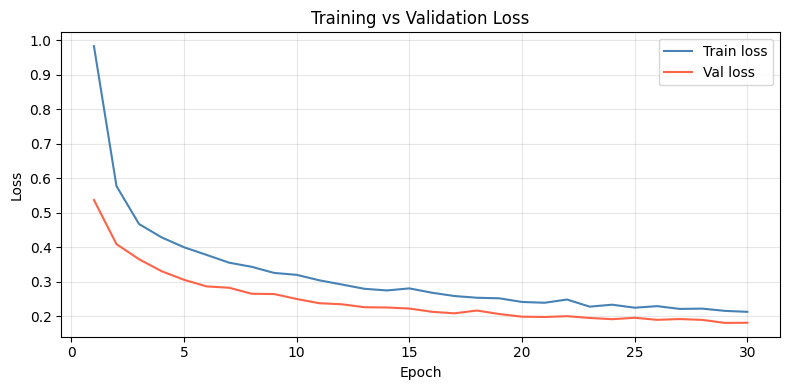

In [23]:
 #  Plot Loss Curves

model.load_state_dict(torch.load("best_model.pth", map_location=device))
print("Best model loaded.")

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, train_losses, label="Train loss",  color="steelblue")
plt.plot(epochs_range, val_losses,   label="Val loss",    color="tomato")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# Evaluate: IoU & Dice Per Class

def evaluate(loader, model, num_classes, ignore_index):
    model.eval()

    tp = np.zeros(num_classes)
    fp = np.zeros(num_classes)
    fn = np.zeros(num_classes)

    with torch.no_grad():
        for imgs, msks in tqdm(loader, desc="Evaluating"):
            imgs = imgs.to(device)
            pred = torch.argmax(model(imgs), dim=1).cpu().numpy().ravel()
            gt   = msks.numpy().ravel()

            valid = gt != ignore_index
            pred, gt = pred[valid], gt[valid]

            for c in range(num_classes - 1):   # skip Unlabeled
                tp[c] += ((pred == c) & (gt == c)).sum()
                fp[c] += ((pred == c) & (gt != c)).sum()
                fn[c] += ((pred != c) & (gt == c)).sum()

    iou  = tp / (tp + fp + fn + 1e-6)
    dice = 2 * tp / (2 * tp + fp + fn + 1e-6)
    return iou, dice


iou, dice = evaluate(val_loader, model, CFG["num_classes"], CFG["ignore_index"])

print(f"\n{'Class':<14} {'IoU':>8} {'Dice':>8}")
print("-" * 32)
for i in range(CFG["num_classes"] - 1):
    print(f"{CLASS_NAMES[i]:<14} {iou[i]:8.4f} {dice[i]:8.4f}")
print("-" * 32)
print(f"{'Mean':<14} {iou[:-1].mean():8.4f} {dice[:-1].mean():8.4f}")

Evaluating: 100%|██████████| 56/56 [00:07<00:00,  7.09it/s]


Class               IoU     Dice
--------------------------------
Building         0.7933   0.8847
Land             0.8742   0.9329
Road             0.6990   0.8228
Vegetation       0.7728   0.8719
Water            0.9479   0.9732
--------------------------------
Mean             0.8174   0.8971


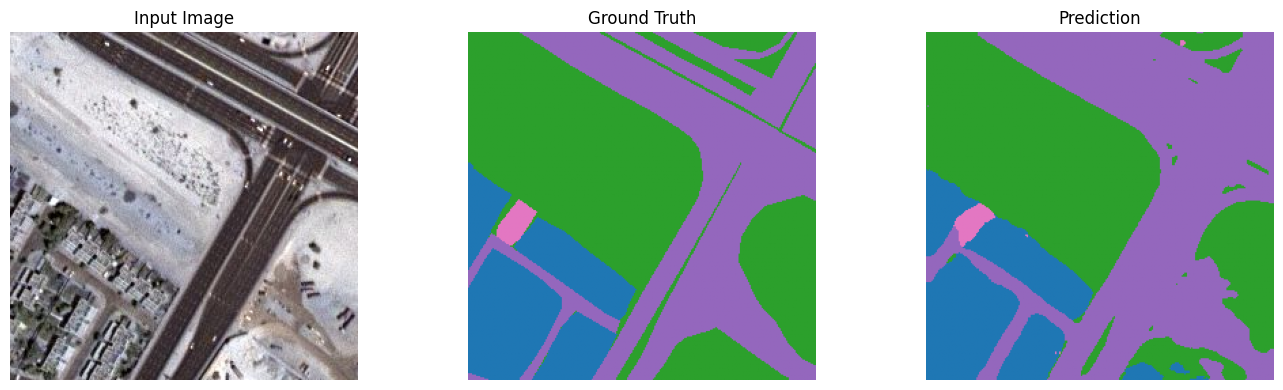

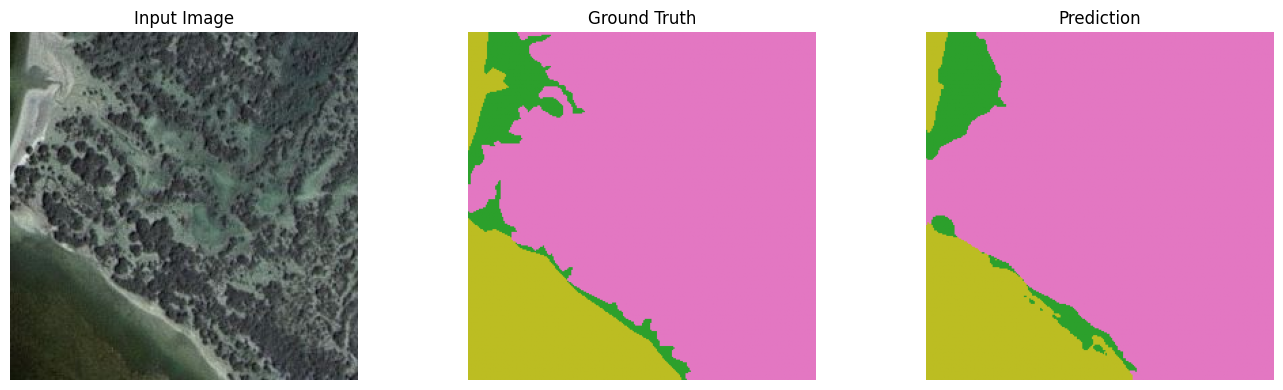

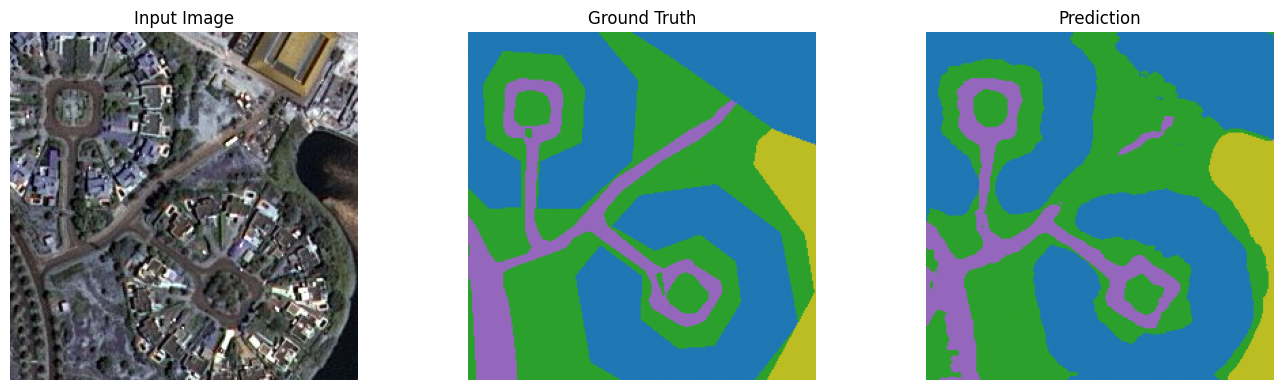

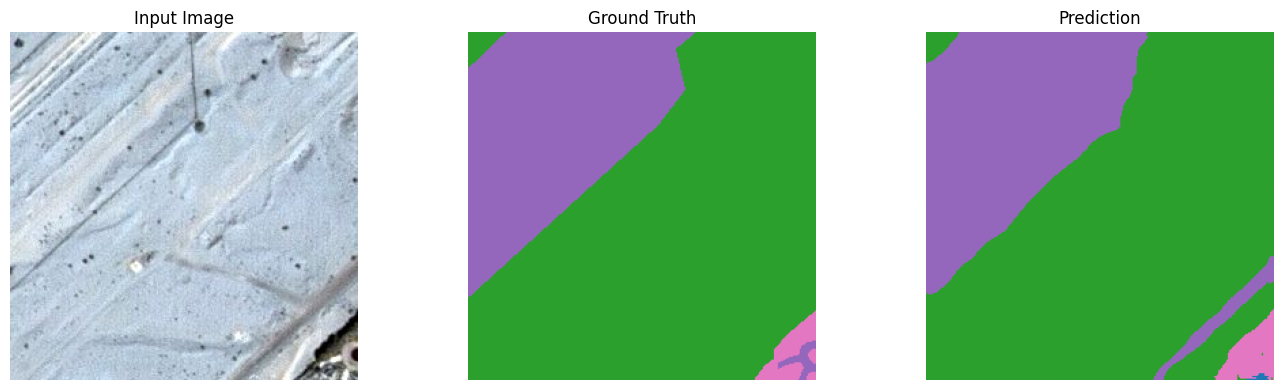

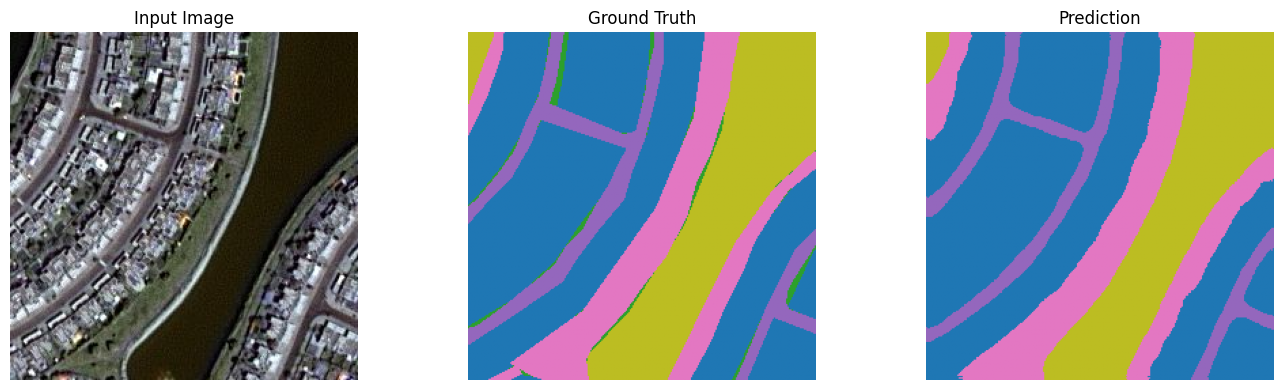

In [25]:
#  Visualise Predictions

# Only show patches that have at least 3 different classes (more interesting)
rich_idx = [i for i in range(len(val_dataset))
            if len(np.unique(y_val[i])) >= 3]

samples = random.sample(rich_idx, min(5, len(rich_idx)))

model.eval()

for idx in samples:
    image, mask = val_dataset[idx]

    with torch.no_grad():
        pred = torch.argmax(
            model(image.unsqueeze(0).to(device)), dim=1
        ).squeeze(0).cpu().numpy()

    # Undo normalisation to show original colours
    img_np = image.permute(1, 2, 0).numpy()
    mean   = np.array([0.485, 0.456, 0.406])
    std    = np.array([0.229, 0.224, 0.225])
    img_np = np.clip(img_np * std + mean, 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(img_np);                              axes[0].set_title("Input Image")
    axes[1].imshow(mask.numpy(), cmap="tab10", vmin=0, vmax=5); axes[1].set_title("Ground Truth")
    axes[2].imshow(pred,         cmap="tab10", vmin=0, vmax=5); axes[2].set_title("Prediction")
    for ax in axes: ax.axis("off")
    plt.tight_layout()
    plt.show()